# Metadata Analysis Notebook

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
METADATA_DIR = PROJECT_ROOT / "metadata"
REPORT_DIR = PROJECT_ROOT / "reports" / "metadata"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
recordings = pd.read_csv(
    METADATA_DIR / "chbmit_recordings.csv"
)

seizures = pd.read_csv(
    METADATA_DIR / "chbmit_seizures.csv"
)

patient_summary = pd.read_csv(
    METADATA_DIR / "chbmit_patient_summary.csv"
)

problems = pd.read_csv(
    METADATA_DIR / "chbmit_metadata_problems.csv"
)

print("Recordings:", recordings.shape)
print("Seizures:", seizures.shape)
print("Cases:", recordings["case_id"].nunique())
print("Problems:", problems.shape)

Recordings: (657, 38)
Seizures: (194, 22)
Cases: 23
Problems: (0, 6)


In [3]:
dataset_statistics = pd.Series(
    {
        "cases": recordings["case_id"].nunique(),
        "recordings": len(recordings),
        "seizure_recordings": recordings[
            "has_seizure"
        ].sum(),
        "seizures": len(seizures),
        "recording_hours": (
            recordings[
                "duration_seconds_edf"
            ].sum()
            / 3600
        ),
        "ictal_minutes": (
            seizures["duration_seconds"].sum()
            / 60
        ),
        "median_seizure_duration_seconds": (
            seizures["duration_seconds"].median()
        ),
        "minimum_seizure_duration_seconds": (
            seizures["duration_seconds"].min()
        ),
        "maximum_seizure_duration_seconds": (
            seizures["duration_seconds"].max()
        ),
    }
)

dataset_statistics

cases                                23.000000
recordings                          657.000000
seizure_recordings                  138.000000
seizures                            194.000000
recording_hours                     905.767222
ictal_minutes                       188.916667
median_seizure_duration_seconds      43.500000
minimum_seizure_duration_seconds      6.000000
maximum_seizure_duration_seconds    752.000000
dtype: float64

# Files for each case

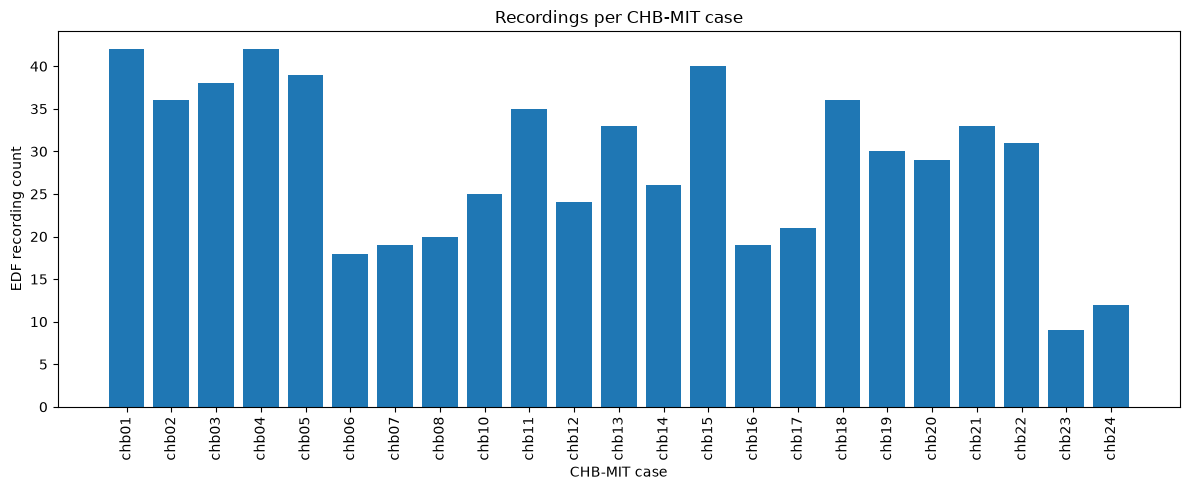

In [4]:
case_recording_counts = (
    recordings.groupby("case_id")
    .size()
    .rename("recording_count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    case_recording_counts["case_id"],
    case_recording_counts["recording_count"],
)

ax.set_xlabel("CHB-MIT case")
ax.set_ylabel("EDF recording count")
ax.set_title("Recordings per CHB-MIT case")
ax.tick_params(axis="x", rotation=90)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "recordings_per_case.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Number of seizures per case

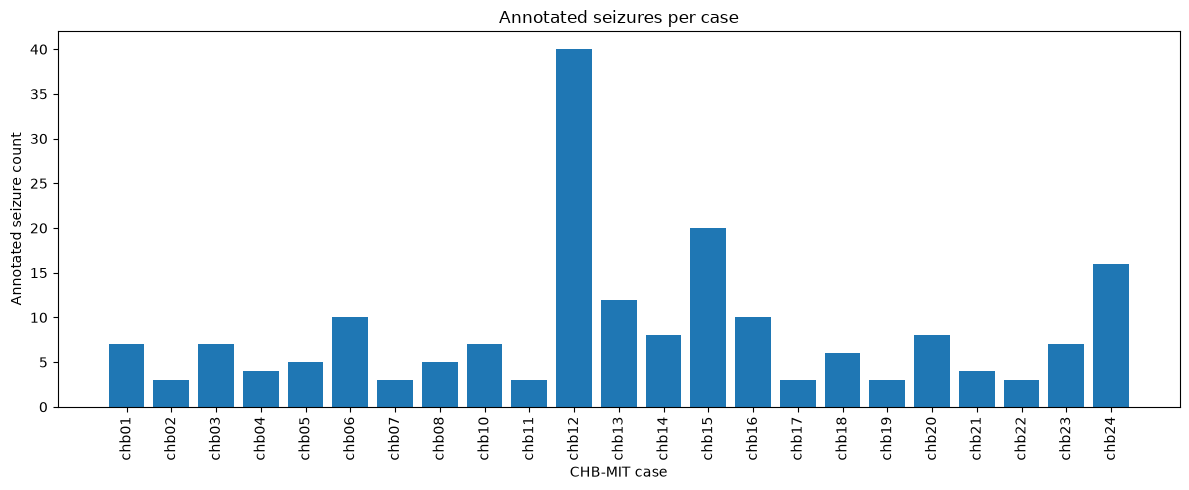

In [5]:
case_seizure_counts = (
    seizures.groupby("case_id")
    .size()
    .rename("seizure_count")
    .reindex(
        recordings["case_id"].drop_duplicates()
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    case_seizure_counts["case_id"],
    case_seizure_counts["seizure_count"],
)

ax.set_xlabel("CHB-MIT case")
ax.set_ylabel("Annotated seizure count")
ax.set_title("Annotated seizures per case")
ax.tick_params(axis="x", rotation=90)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "seizures_per_case.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Seizure duration distribution

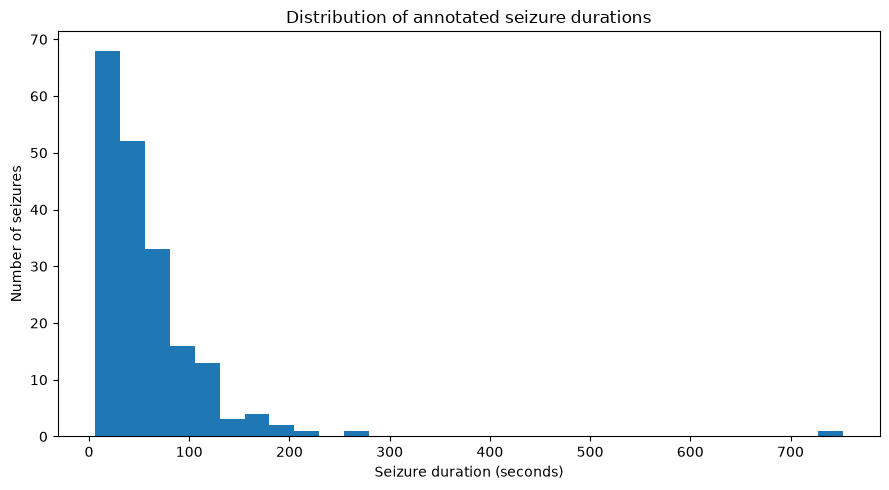

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    seizures["duration_seconds"],
    bins=30,
)

ax.set_xlabel("Seizure duration (seconds)")
ax.set_ylabel("Number of seizures")
ax.set_title("Distribution of annotated seizure durations")

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "seizure_duration_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Duration of registrations

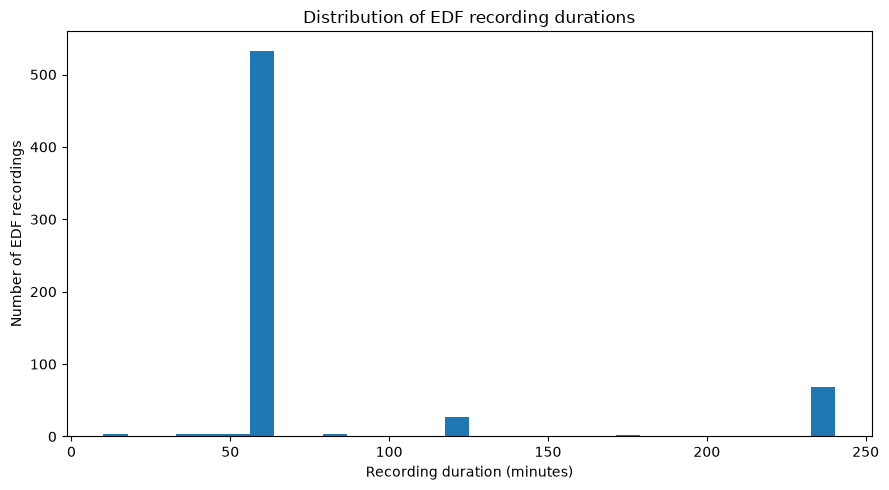

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    recordings["duration_seconds_edf"] / 60,
    bins=30,
)

ax.set_xlabel("Recording duration (minutes)")
ax.set_ylabel("Number of EDF recordings")
ax.set_title("Distribution of EDF recording durations")

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "recording_duration_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Total ictal time for each case

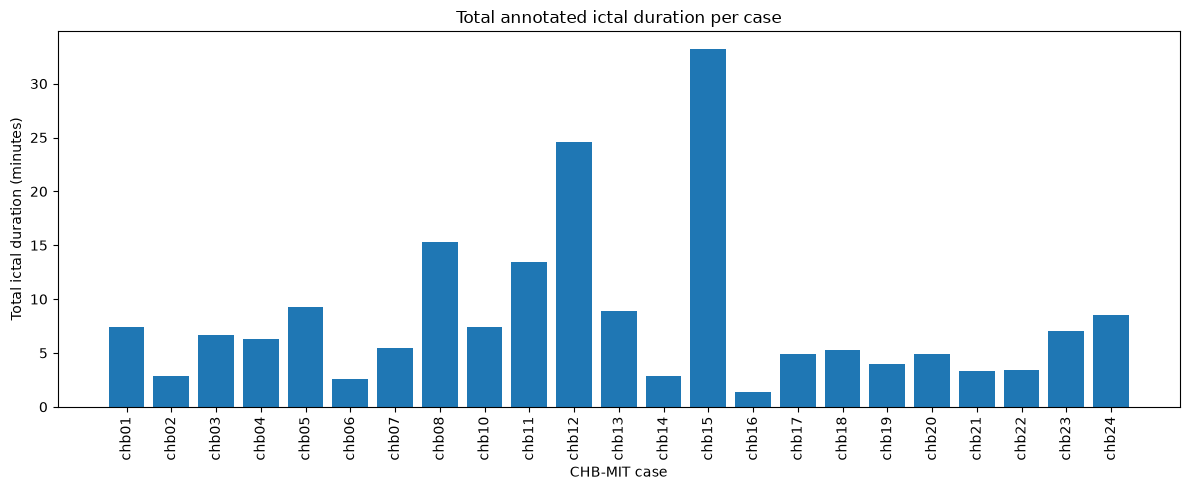

In [8]:
case_ictal_duration = (
    seizures.groupby("case_id")[
        "duration_seconds"
    ]
    .sum()
    .rename("ictal_seconds")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    case_ictal_duration["case_id"],
    case_ictal_duration["ictal_seconds"] / 60,
)

ax.set_xlabel("CHB-MIT case")
ax.set_ylabel("Total ictal duration (minutes)")
ax.set_title("Total annotated ictal duration per case")
ax.tick_params(axis="x", rotation=90)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "ictal_duration_per_case.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()